<a href="https://colab.research.google.com/github/LeoFairley123/EMSC2010-Individual-Project/blob/main/EMSC2010_Individual_Project_U7488277.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Title**

# **Three-Layer Earth Energy Balance Model**

I constructed a three-layer energy balance model representing interactions between the atmosphere, the surface (land + upper ocean), and the deep ocean. The system is driven by radiative forcing, ocean heat uptake, and time-varying external forcing.

**Model Structure**

The model consists of three coupled temperature variables:

* $T_a$: atmospheric temperature
* $T_s$: surface temperature (land + mixed ocean layer)
* $T_d$: deep ocean temperature

Energy conservation is applied to each layer, balancing incoming and outgoing radiative and turbulent fluxes.

**Atmospheric Energy Balance**

The atmosphere exchanges energy with the surface through infrared radiation and turbulent heat fluxes. Its energy balance is:

\begin{equation}
C_a \frac{dT_a}{dt} =
\epsilon_a \sigma T_s^4
-
2 \epsilon_a \sigma T_a^4
+
k (T_s - T_a)
\end{equation}

where:

* $C_a$ is atmospheric heat capacity
* $\epsilon_a$ is atmospheric emissivity
* $\sigma$ is the Stefan-Boltzmann constant
* $k$ is the surface-atmosphere heat exchange coefficient

The first term represents infrared radiation absorbed from the surface, the second term represents atmospheric emission upward and downward, and the third term represents sensible and latent heat exchange.

**Surface Energy Balance**

The surface layer receives solar radiation, atmospheric radiation, and loses energy via infrared emission and heat exchange with both the atmosphere and deep ocean:

\begin{equation}
C_s \frac{dT_s}{dt}
=
\frac{(1 - \alpha(T_s)) S(t)}{4}
+
\epsilon_a \sigma T_a^4
-
\sigma T_s^4
-
k (T_s - T_a)
-
\gamma (T_s - T_d)
+
F_{CO_2}(t)
+
\eta(t)
\end{equation}

where:

* $C_s$ is surface heat capacity
* $\alpha(T_s)$ is temperature-dependent albedo
* $S(t)$ is time-dependent solar insolation
* $\gamma$ is ocean heat exchange coefficient
* $F_{CO_2}(t)$ is radiative forcing from CO$_2$
* $\eta(t)$ represents random weather variability

**Deep Ocean Energy Balance**

The deep ocean exchanges heat only with the surface layer:

\begin{equation}
C_d \frac{dT_d}{dt}
=
\gamma (T_s - T_d)
\end{equation}

where
* $C_d$ is the deep ocean heat capacity

**External Forcing**

**Solar Forcing**

Incoming solar radiation is prescribed as a periodic function:

\begin{equation}
S(t) = S_0 + A \sin ( \frac{2 \pi t}{P})
\end{equation}

where:
* $S_0$ is the mean solar constant
* $A$ is the amplitude of variability
* $P$ is the period of solar oscillation

**CO$_2$ Radiative Forcing**

Greenhouse forcing is parameterised using a logarithmic relationship:

\begin{equation}
F_{CO_2}(t)
=
5.35 \ln ( \frac{C(t)}{C_0})
\end{equation}

where:
* $C(t)$ is atmospheric CO$_2$ concentration
* $C_0$ is the pre-industrial reference concentration

CO$_2$ concentration evolves as:

\begin{equation}
C(t) = C_0 + r t
\end{equation}

where:
* $r$ is the growth rate.

**Albedo Feedback**

Planetary albedo depends on surface temperature:

\begin{equation}
\alpha(T_s)
=
\alpha_{\min}
+
\frac{\alpha_{\max} - \alpha_{\min}}
{1 + e^{( \frac{T_s - T_c}{\Delta T})}}
\end{equation}

This represents ice-albedo feedback, where colder temperatures increase reflectivity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Define constants
sigma            = 5.67e-8
C_s = 0.7 * 1025 * 4000 * 50 + 0.3 * 1000 * 800 * 2
C_a1 = 0.7e7
C_a2 = 1.5e7
C_d = 1025 * 4000 * 3800              # ≈ 1.56e10 J/m²/K  deep ocean
C0              = 280
CO2_growth_rate = 2.0
epsilon         = 0.484
gamma           = 0.5                  # W/m²/K  surface–deep ocean exchange
alpha_min = 0.245
alpha_max = 0.80
T_ice     = 263.15   # K — centre of ice transition (~-10°C)
delta_T   = 10.0     # K — transition width
A_cycle = 0.5    # W/m²  — amplitude (half of ~1 W/m² peak-to-peak observed TSI range)
P_cycle = 11.0   # years — solar cycle period
S0 = 1361
eruption_probability = 0.01   # chance per timestep

In [ ]:
# Initialise time steps

years   = 1000
dt      = 0.001
n_steps = int(years / dt)
seconds_per_year = 365 * 24 * 3600
dt_sec  = dt * seconds_per_year
time    = np.linspace(0, years, n_steps)

In [2]:
# Initialise arrays

Ts  = np.zeros(n_steps)
Ta2 = np.zeros(n_steps)
Ta1 = np.zeros(n_steps)
Td  = np.zeros(n_steps)               # deep ocean
F_volc = np.zeros(n_steps)

for i in range(n_steps):

    # Random eruption occurs
    if np.random.rand() < eruption_probability * dt:

        # One-sided normal distribution for strength (always negative cooling)
        strength = -np.abs(np.random.normal(loc=0, scale=2.5))
        strength = np.clip(strength, -8, -0.1)

        # Recovery timescale (years)
        tau = np.random.uniform(1, 3)

        # Apply exponential decay
        for j in range(i, n_steps):

            t_since = time[j] - time[i]

            F_volc[j] += strength * np.exp(-t_since / tau)


Ts[0]  = 287.41
Ta2[0] = 252.69
Ta1[0] = 229.07
Td[0]  = 277.41                        # 4°C — observed deep ocean mean

for i in range(n_steps - 1):
    t     = time[i]
    S = S0 + A_cycle * np.sin(2 * np.pi * t / P_cycle)

    alpha = alpha_max - (
    (alpha_max - alpha_min)
    / (1 + np.exp(-(Ts[i] - T_ice)/delta_T)))

    CO2   = C0 + CO2_growth_rate * t
    if CO2 < 1:
       CO2 = 1
    F_co2 = 5.35 * np.log(CO2 / C0)

    noise = np.random.normal(0, 7)

    dTs_dt = (
          (1 - alpha) * S / 4
        + epsilon * sigma * Ta2[i]**4
        + (1 - epsilon) * epsilon * sigma * Ta1[i]**4
        - sigma * Ts[i]**4
        + F_co2
        - gamma * (Ts[i] - Td[i])
        + F_volc[i]
        + noise
      ) / C_s

    dTa2_dt = (
          epsilon * sigma * Ts[i]**4
        + epsilon**2 * sigma * Ta1[i]**4
        - 2 * epsilon * sigma * Ta2[i]**4
      ) / C_a2

    dTa1_dt = (
          epsilon * (1 - epsilon) * sigma * Ts[i]**4
        + epsilon**2 * sigma * Ta2[i]**4
        - 2 * epsilon * sigma * Ta1[i]**4
      ) / C_a1

    dTd_dt = (
        gamma * (Ts[i] - Td[i])        # slow equilibration toward surface
      ) / C_d

    Ts[i+1]  = Ts[i]  + dTs_dt  * dt_sec
    Ta2[i+1] = Ta2[i] + dTa2_dt * dt_sec
    Ta1[i+1] = Ta1[i] + dTa1_dt * dt_sec
    Td[i+1]  = Td[i]  + dTd_dt  * dt_sec

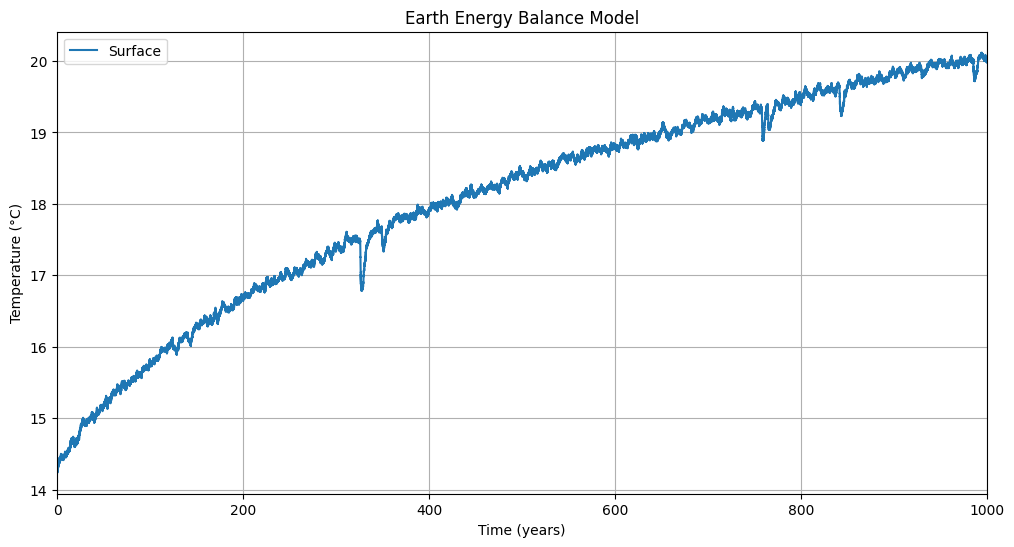

In [3]:
# Plot model

plt.figure(figsize=(12, 6))

plt.plot(time, Ts - 273.15, label='Surface')
#plt.plot(time, Ta2 - 273.15, label='Ta2')
#plt.plot(time, Ta1 - 273.15, label='Ta1')
#plt.plot(time, Td - 273.15, label='Deep Ocean')
plt.xlim(0,years)
plt.xlabel('Time (years)')
plt.ylabel('Temperature (°C)')
plt.title('Earth Energy Balance Model')

plt.legend()
plt.grid(True)

plt.show()